## **Trabalho Prático Final - Fundamentos em Ciências de Dados**
### **Grupo 2:**
**-** Cauã Honorato De Paula **- NUSP:** 17151824

**-** Leonardo Brito da Silva **- NUSP:** 16908565

---

### (1) Descrição do problema e dos dados

**• Apresentar o tema escolhido:**
O tema central deste trabalho é a análise do impacto demográfico e da evolução temporal da mortalidade durante a pandemia de COVID-19 no Brasil. O estudo busca compreender as variações do impacto do vírus entre diferentes regiões e investigar indícios de subnotificação de COVID-19 através da análise de mortes por causas respiratórias secundárias.

**• Descrever a origem da base de dados:**

Os dados utilizados neste trabalho foram extraídos do projeto colaborativo Brasil.io, disponíveis publicamente no repositório https://brasil.io/dataset/covid19/files/. Este portal compila e padroniza informações epidemiológicas das Secretarias de Saúde e registros cartoriais de óbitos no Brasil. Além do download direto dos arquivos, a plataforma também disponibiliza uma **API** (https://brasil.io/api/dataset/covid19/) para o consumo programático das informações, acompanhada de uma **documentação técnica** detalhada (https://github.com/turicas/covid19-br/blob/master/api.md) que descreve a estrutura de todas as variáveis e *endpoints*.

A base de dados estruturada inclui variáveis demográficas, como a população estimada (`estimated_population`), e dados epidemiológicos contínuos de casos e óbitos (`confirmed`, `deaths`). Um diferencial importante desta base é o detalhamento de óbitos por diferentes causas respiratórias (como `deaths_pneumonia_2019`, `deaths_pneumonia_2020`, `deaths_sars_2019` e `deaths_sars_2020`), possibilitando uma comparação temporal direta da mortalidade entre os anos de 2019 e 2020.

**• Explicar os objetivos ou perguntas que serão investigadas:**
O objetivo principal é aplicar técnicas de análise exploratória de dados para identificar padrões e tendências na mortalidade durante a pandemia. As principais perguntas investigadas serão:
1. Como a taxa de mortalidade e a incidência de casos
(`death_rate` e `confirmed_per_100k_inhabitants`) variaram entre os diferentes estados (`state`)
2. Municípios mais populosos (`estimated_population`) tiveram maior taxa de mortalidade proporcional, ou o interior foi igualmente afetado?
3. Existe correlação entre densidade populacional e velocidade de disseminação da doença?
4. Estados com baixa notificação oficial de COVID-19 apresentaram maior excesso de mortes respiratórias em 2020, sugerindo subnotificação sistemática?
5. Existe um desvio perceptível no padrão sazonal de óbitos por causas respiratórias (pneumonia, SRAG e insuficiência respiratória) em 2020 comparado a 2019? Esse possível excesso de mortalidade apresenta associação temporal com os picos de óbitos por COVID-19?

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Lendo os arquivos...")

df_covid = pd.read_csv('/content/drive/MyDrive/caso_full.csv.gz', compression='gzip')
df_caso = pd.read_csv('/content/drive/MyDrive/caso.csv.gz', compression='gzip')
df_obito =  pd.read_csv('/content/drive/MyDrive/obito_cartorio.csv.gz', compression='gzip')
df_boletim =  pd.read_csv('/content/drive/MyDrive/boletim.csv.gz', compression='gzip')


df_covid.info()
df_caso.info()
df_obito.info()
df_boletim.info()

Lendo os arquivos...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3853648 entries, 0 to 3853647
Data columns (total 18 columns):
 #   Column                                         Dtype  
---  ------                                         -----  
 0   city                                           object 
 1   city_ibge_code                                 float64
 2   date                                           object 
 3   epidemiological_week                           int64  
 4   estimated_population                           float64
 5   estimated_population_2019                      float64
 6   is_last                                        bool   
 7   is_repeated                                    bool   
 8   last_available_confirmed                       int64  
 9   last_available_confirmed_per_100k_inhabitants  float64
 10  last_available_date                            object 
 11  last_available_death_rate                      float64
 12  last_available_deaths

### (2) Preparação dos dados
1. Identificar e tratar valores ausentes ou inconsistentes;
2. Remover duplicidades, quando necessário;
3. Descrever as etapas de limpeza e pré-processamento dos dados

Os conjuntos extraidos (`boletim`, `caso`, `caso_full` e `obito_cartorio`) passaram por etapas de limpeza e pré-processamento utilizando a biblioteca `pandas` em Python. As ações realizadas foram:

**• Identificar e tratar valores ausentes ou inconsistentes:**
A avaliação das tabelas indicou a presença de valores nulos em bases específicas:
1. Na tabela `obito_cartorio`, que possui um total de 9.882 registros, as variáveis que contabilizam novos óbitos diários (como `new_deaths_sars_2019`, `new_deaths_covid19`, entre outras) apresentavam milhares de valores nulos. Essas inconsistências foram tratadas preenchendo as lacunas com o valor `0` (zero), adotando que a ausência do dado indica que não houve ocorrência daquela causa de morte no respectivo dia.
2. Na tabela `boletim`, de um total de 20.827 registros, a coluna textual `notes` possuía apenas 6.565 campos preenchidos. Os espaços vazios restantes foram padronizados com a descrição `"Sem nota"`.

In [ ]:
# Lista com as colunas de 'new_deaths' da tabela obito_cartorio que possuem nulos
colunas_novos_obitos = [
    'new_deaths_indeterminate_2019', 'new_deaths_respiratory_failure_2019',
    'new_deaths_others_2019', 'new_deaths_pneumonia_2019', 'new_deaths_septicemia_2019',
    'new_deaths_sars_2019', 'new_deaths_covid19', 'new_deaths_indeterminate_2020',
    'new_deaths_respiratory_failure_2020', 'new_deaths_others_2020',
    'new_deaths_pneumonia_2020', 'new_deaths_septicemia_2020', 'new_deaths_sars_2020'
]

# Preenche os valores ausentes de mortes com 0 na tabela obito_cartorio
df_obito[colunas_novos_obitos] = df_obito[colunas_novos_obitos].fillna(0)

# Preenche as notas ausentes com 'Sem nota' na tabela boletim
df_boletim['notes'] = df_boletim['notes'].fillna('Sem nota')


**• Remover duplicidades, quando necessário:**
Aplicou-se o método `drop_duplicates()` nas quatro tabelas utilizadas. Essa etapa de limpeza é fundamental ao lidar com bases de dados de saúde pública, mitigando o risco de que eventuais erros de dupla inserção nos sistemas das secretarias de saúde inflem artificialmente o número de casos e óbitos nas análises.


In [ ]:
df_boletim = df_boletim.drop_duplicates()
df_covid = df_covid.drop_duplicates()
df_caso = df_caso.drop_duplicates()
df_obito = df_obito.drop_duplicates()

**• Descrever as etapas de limpeza e pré-processamento dos dados:**
A inspeção dos tipos de dados revelou que a maioria das variáveis demográficas e epidemiológicas (como `estimated_population`, `confirmed`, `deaths` e `death_rate`) foi importada corretamente em formatos numéricos (`int64` e `float64`). Sendo assim, a etapa  de pré-processamento está limitada à **Conversão Temporal**.As colunas de data (`date` em todas as tabelas, além da `last_available_date` em `caso_full`) constavam com o tipo `object` (formato de texto). Elas foram convertidas para o formato `datetime`, a fim de viabilizar as futuras visualizações gráficas de série temporal.

In [ ]:
df_boletim['date'] = pd.to_datetime(df_boletim['date'])
df_covid['date'] = pd.to_datetime(df_covid['date'])
df_caso['date'] = pd.to_datetime(df_caso['date'])
df_obito['date'] = pd.to_datetime(df_obito['date'])

In [ ]:
df_caso.head()

,date,state,city,place_type,confirmed,deaths,order_for_place,is_last,estimated_population_2019,estimated_population,city_ibge_code,confirmed_per_100k_inhabitants,death_rate
0,2022-03-27,AP,NaN,state,160328,2122,734,True,845731.0,861773.0,16.0,18604.43527,0.0132
1,2022-03-26,AP,NaN,state,160321,2122,733,False,845731.0,861773.0,16.0,18603.62300,0.0132
2,2022-03-25,AP,NaN,state,160314,2122,732,False,845731.0,861773.0,16.0,18602.81072,0.0132
3,2022-03-24,AP,NaN,state,160301,2122,731,False,845731.0,861773.0,16.0,18601.30220,0.0132
4,2022-03-23,AP,NaN,state,160288,2122,730,False,845731.0,861773.0,16.0,18599.79368,0.0132


**Observação sobre a estrutura da base (`caso_full`):** ao inspecionar `df_covid.head()` percebe-se que muitas linhas trazem `city` igual a `NaN` e `city_ibge_code` com apenas 2 dígitos (ex.: `12`), enquanto outras trazem o nome do município e um código IBGE de 7 dígitos (ex.: `1200401`, Rio Branco). Isso não é um erro nem dado corrompido: a tabela `caso_full.csv` mistura, na mesma estrutura, duas granularidades diferentes, distinguidas pela coluna `place_type`:

- `place_type == "city"` → uma linha por município, por data;
- `place_type == "state"` → uma linha-resumo do estado inteiro, por data (sem nome de cidade, com o código IBGE do estado).

Ou seja, para cada estado e data existe tanto o detalhamento por município quanto uma linha agregada do estado. Se essa distinção não for considerada, qualquer análise feita por município ficaria contaminada pelas linhas agregadas de estado (e vice-versa), inflando contagens e distorcendo médias/medianas. Por isso, antes de qualquer análise, separamos explicitamente `df_state` (`place_type == "state"`) de `df_city` (`place_type == "city"`), além de manter apenas o registro mais recente de cada localidade (`is_last == True`).

### (3) Análise exploratória dos dados

Realizar análises utilizando tabelas e gráficos para responder às perguntas propostas.

**Exemplos:**
* Distribuição das variáveis;
* Comparação entre grupos;
* Associações entre variáveis;
* Identificação de padrões ou tendências.

Devem ser utilizados pelo menos três tipos diferentes de visualização de dados, como histogramas, gráficos de barras, gráficos de dispersão, boxplots, entre outros.

Para esta análise utilizamos as colunas mais recentes de `caso_full` (`df_covid`, com `is_last == True`), separadas em nível de **estado** (`place_type == "state"`) e em nível de **município** (`place_type == "city"`).

In [ ]:
df_state = df_covid[(df_covid["place_type"] == "state") & (df_covid["is_last"] == True)].copy()
df_city = df_covid[(df_covid["place_type"] == "city") & (df_covid["is_last"] == True)].copy()

df_state = df_state.rename(columns={
    "last_available_death_rate": "death_rate",
    "last_available_confirmed_per_100k_inhabitants": "confirmed_per_100k_inhabitants",
    "last_available_confirmed": "confirmed",
    "last_available_deaths": "deaths",
})
df_city = df_city.rename(columns={
    "last_available_death_rate": "death_rate",
    "last_available_confirmed_per_100k_inhabitants": "confirmed_per_100k_inhabitants",
    "last_available_confirmed": "confirmed",
    "last_available_deaths": "deaths",
})

df_state = df_state.dropna(subset=["death_rate", "confirmed_per_100k_inhabitants"])
df_city = df_city.dropna(subset=["death_rate", "confirmed_per_100k_inhabitants", "estimated_population"])

print(df_state.shape, df_city.shape)
df_state[["state", "confirmed", "deaths", "death_rate", "confirmed_per_100k_inhabitants"]].describe()


(27, 18) (5570, 18)


,confirmed,deaths,death_rate,confirmed_per_100k_inhabitants
count,2.700000e+01,27.000000,27.000000,27.000000
mean,1.105546e+06,24413.296296,0.019848,15922.713939
std,1.149918e+06,33448.372206,0.005340,5364.162734
min,1.238080e+05,1992.000000,0.013000,5962.374820
25%,3.797290e+05,7446.500000,0.016550,11637.056355
50%,6.913530e+05,14151.000000,0.019400,14727.660420
75%,1.399954e+06,26460.000000,0.022350,20184.538925
max,5.232374e+06,167110.000000,0.035000,25521.031720


**3.2 Pergunta 1 - Variação de `death_rate` e `confirmed_per_100k_inhabitants` entre estados**

Gráficos de barras comparando os estados, ordenados do maior para o menor valor.


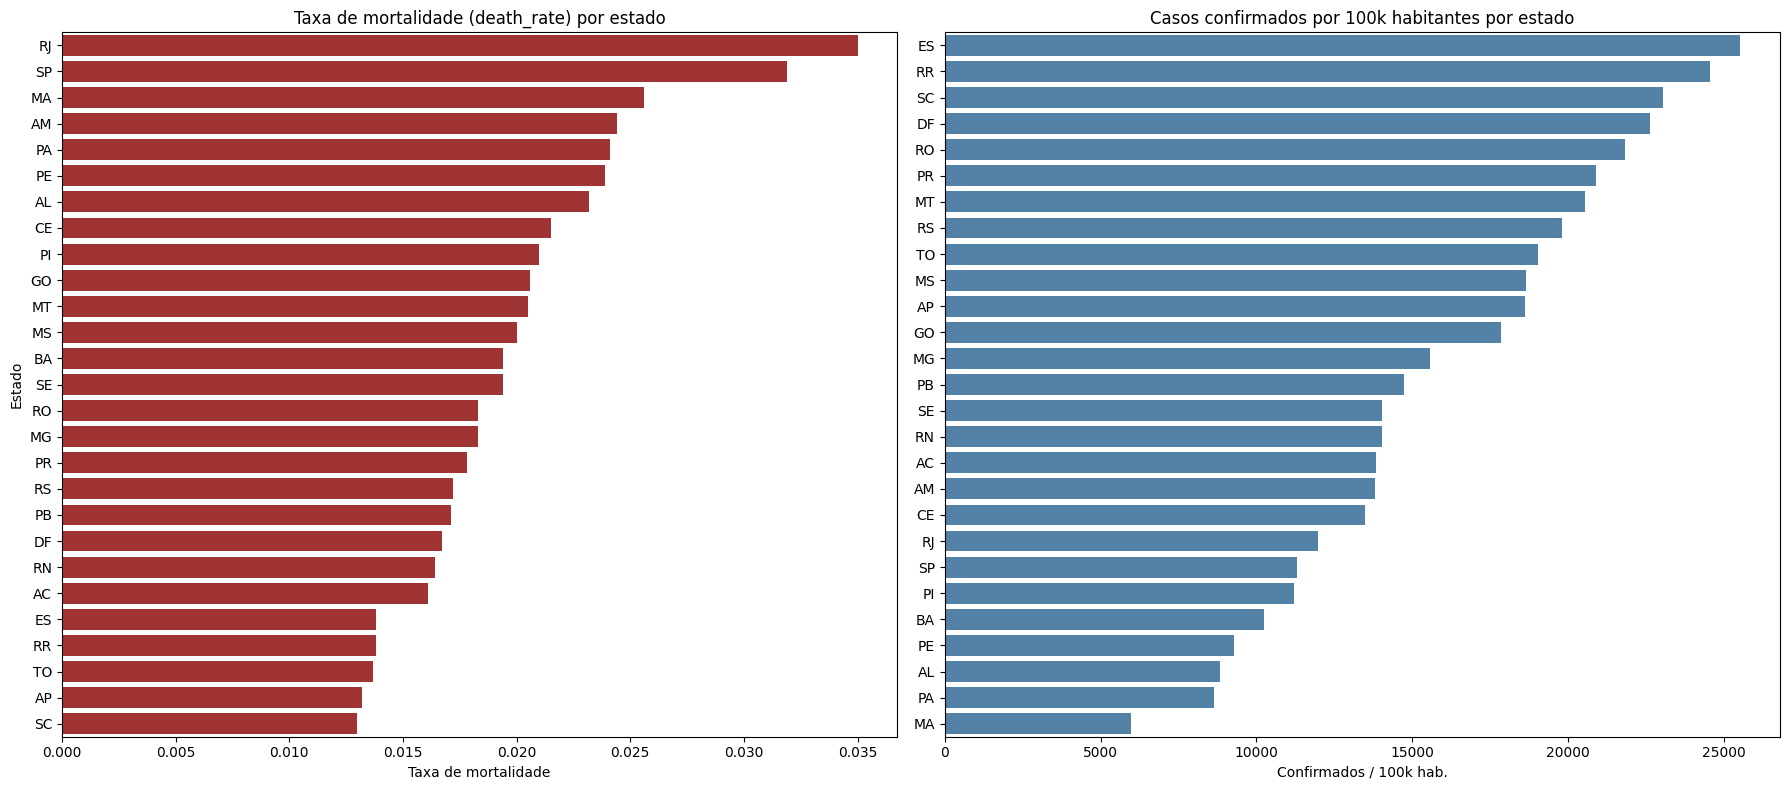

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

order1 = df_state.sort_values("death_rate", ascending=False)
sns.barplot(data=order1, x="death_rate", y="state", ax=axes[0], color="firebrick")
axes[0].set_title("Taxa de mortalidade (death_rate) por estado")
axes[0].set_xlabel("Taxa de mortalidade")
axes[0].set_ylabel("Estado")

order2 = df_state.sort_values("confirmed_per_100k_inhabitants", ascending=False)
sns.barplot(data=order2, x="confirmed_per_100k_inhabitants", y="state", ax=axes[1], color="steelblue")
axes[1].set_title("Casos confirmados por 100k habitantes por estado")
axes[1].set_xlabel("Confirmados / 100k hab.")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


**Interpretação:** os gráficos de barras evidenciam grande heterogeneidade entre estados, tanto na letalidade aparente (`death_rate`) quanto na incidência (`confirmed_per_100k_inhabitants`). Chama atenção um padrão específico: RJ, SP e MA aparecem entre os estados com **maior** taxa de mortalidade, mas figuram entre os de **menor** incidência normalizada (RJ e SP nas últimas posições, MA na última). Esse descompasso sugere que, nesses estados, uma fração relativamente menor de casos foi oficialmente confirmada por habitante, possivelmente por menor capacidade de testagem, levando à confirmação predominante dos casos mais graves (que evoluem a óbito), aumentando artificialmente a `death_rate` calculada sobre os casos confirmados, em vez de refletir necessariamente maior letalidade real do vírus nesses locais.

**3.3 Pergunta 2 - Municípios mais populosos vs. interior**

Para comparar municípios por porte populacional, dividimos `estimated_population` em quartis a partir dos percentis calculados com `np.percentile` (visto na disciplina) e usamos `pd.cut` para classificar cada município no seu respectivo quartil.


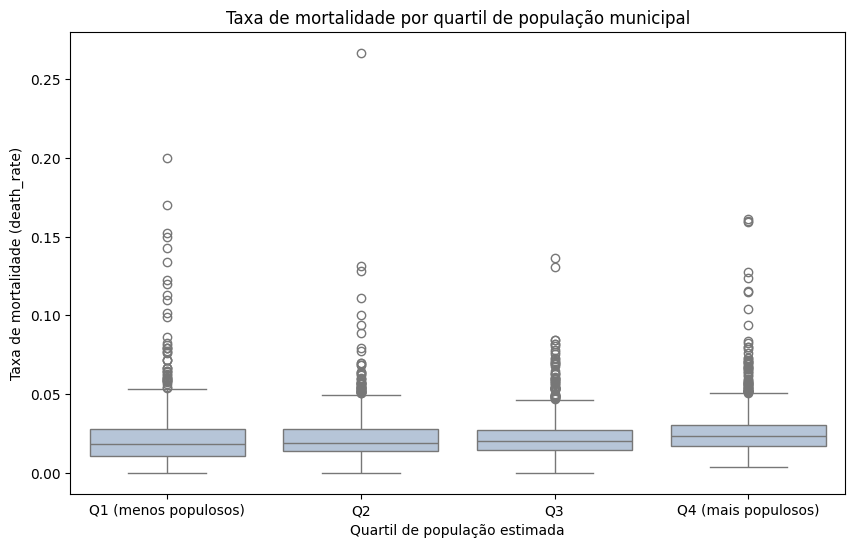

,count,mean,std,min,25%,50%,75%,max
pop_quartil,,,,,,,,
Q1 (menos populosos),1393.0,0.021589,0.017075,0.0000,0.0109,0.0183,0.027900,0.2000
Q2,1392.0,0.021976,0.014490,0.0000,0.0135,0.0190,0.028025,0.2667
Q3,1392.0,0.022432,0.012373,0.0000,0.0144,0.0203,0.027125,0.1364
Q4 (mais populosos),1393.0,0.025777,0.014548,0.0035,0.0170,0.0232,0.030500,0.1611


In [ ]:
p25, p50, p75 = np.percentile(df_city["estimated_population"], [25, 50, 75])
bordas = [0, p25, p50, p75, df_city["estimated_population"].max()]
rotulos = ["Q1 (menos populosos)", "Q2", "Q3", "Q4 (mais populosos)"]

df_city["pop_quartil"] = pd.cut(df_city["estimated_population"], bins=bordas, labels=rotulos, include_lowest=True)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_city, x="pop_quartil", y="death_rate", color="lightsteelblue")
plt.title("Taxa de mortalidade por quartil de população municipal")
plt.xlabel("Quartil de população estimada")
plt.ylabel("Taxa de mortalidade (death_rate)")
plt.show()

df_city.groupby("pop_quartil", observed=True)["death_rate"].describe()


**Interpretação:** o boxplot mostra que a mediana de `death_rate` é muito semelhante entre os quatro quartis de população (entre ~0,018 e ~0,022), com Q4 (municípios mais populosos) apresentando uma mediana apenas marginalmente mais alta. A diferença mais notável não está no centro da distribuição, mas nos **outliers**: Q1, Q2 e Q3 (municípios menores/interior) concentram muito mais valores extremos de `death_rate` (alguns acima de 0,15, chegando a 0,265 em Q3) do que Q4, cujos outliers ficam mais contidos (até ~0,16). Ou seja, municípios pequenos/de interior tendem a apresentar mais casos isolados de taxa de mortalidade muito alta, provavelmente por terem poucos casos confirmados no total, o que faz cada óbito pesar proporcionalmente muito mais no cálculo de `death_rate`, enquanto os municípios mais populosos (Q4), por terem uma base maior de casos, têm uma taxa de mortalidade mais estável e menos sujeita a esses picos extremos.

**3.4 Pergunta 3 - Porte populacional x velocidade de disseminação**

Como proxy do porte populacional/densidade urbana (a base não traz área territorial), usamos `estimated_population` e relacionamos com `confirmed_per_100k_inhabitants`, que normaliza a incidência pela população, permitindo comparar a velocidade de disseminação relativa entre municípios de tamanhos distintos.


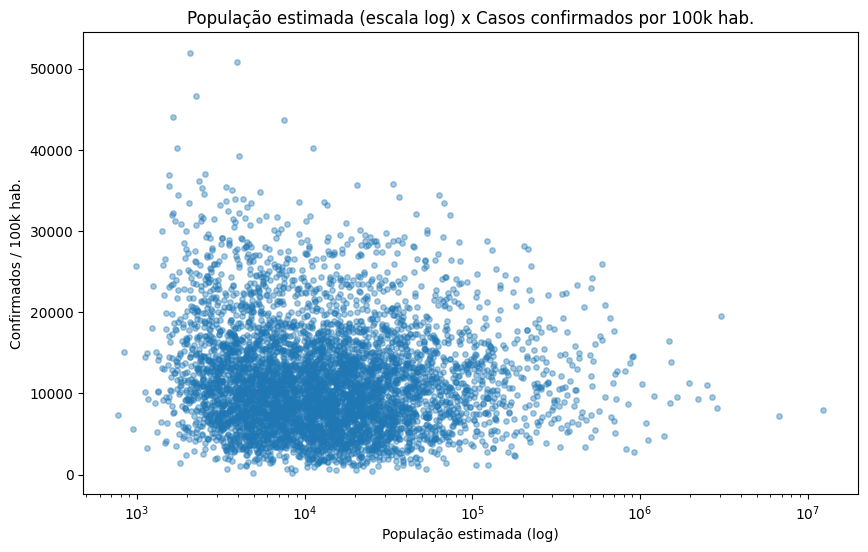

Matriz de correlação (log população x incidência):
[[ 1.         -0.07814312]
 [-0.07814312  1.        ]]
Coeficiente de correlação de Pearson: r = -0.078


In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_city["estimated_population"], df_city["confirmed_per_100k_inhabitants"], alpha=0.4, s=15)
plt.xscale("log")
plt.title("População estimada (escala log) x Casos confirmados por 100k hab.")
plt.xlabel("População estimada (log)")
plt.ylabel("Confirmados / 100k hab.")
plt.show()

matriz_corr = np.corrcoef(np.log10(df_city["estimated_population"]), df_city["confirmed_per_100k_inhabitants"])
print("Matriz de correlação (log população x incidência):")
print(matriz_corr)
print(f"Coeficiente de correlação de Pearson: r = {matriz_corr[0, 1]:.3f}")


**Interpretação:** o gráfico de dispersão mostra uma nuvem concentrada e sem tendência visual clara entre o porte populacional (em escala log) e a incidência normalizada, e o coeficiente de correlação de Pearson calculado (`r ≈ -0,078`) confirma essa leitura: a associação é praticamente nula, levemente negativa. Ou seja, **não há evidência, nesta base, de que municípios maiores tenham tido disseminação proporcionalmente mais rápida da doença**

**3.5 Pergunta 4 - Indícios de subnotificação: óbitos oficiais de COVID-19 x excesso de mortes respiratórias**

Usamos a tabela `obito_cartorio`, que traz óbitos por causas respiratórias em 2019 e 2020 por estado (registros de cartório). Agregamos por estado com `groupby().sum()` e calculamos o excesso de mortes respiratórias em 2020 (pneumonia + SRAG + insuficiência respiratória) frente a 2019, comparando-o com os óbitos oficiais por COVID-19 registrados pelas Secretarias de Saúde (`deaths`, em `df_state`).


In [ ]:
state_resp = df_obito.groupby("state").agg(
    pneumonia_2019=("new_deaths_pneumonia_2019", "sum"),
    sars_2019=("new_deaths_sars_2019", "sum"),
    fail_2019=("new_deaths_respiratory_failure_2019", "sum"),
    pneumonia_2020=("new_deaths_pneumonia_2020", "sum"),
    sars_2020=("new_deaths_sars_2020", "sum"),
    fail_2020=("new_deaths_respiratory_failure_2020", "sum"),
).reset_index()

state_resp["total_resp_2019"] = state_resp["pneumonia_2019"] + state_resp["sars_2019"] + state_resp["fail_2019"]
state_resp["total_resp_2020"] = state_resp["pneumonia_2020"] + state_resp["sars_2020"] + state_resp["fail_2020"]
state_resp["excesso_resp"] = state_resp["total_resp_2020"] - state_resp["total_resp_2019"]

covid_oficial = df_state.set_index("state")["deaths"]
state_resp["covid_oficial_saude"] = state_resp["state"].map(covid_oficial)
state_resp["razao_excesso_oficial"] = state_resp["excesso_resp"] / state_resp["covid_oficial_saude"]

state_resp.sort_values("razao_excesso_oficial", ascending=False)


,state,pneumonia_2019,sars_2019,fail_2019,pneumonia_2020,sars_2020,fail_2020,total_resp_2019,total_resp_2020,excesso_resp,covid_oficial_saude,razao_excesso_oficial
9,MA,2540.0,7.0,1856.0,2267.0,859.0,2231.0,4403.0,5357.0,954.0,10869,0.087773
2,AM,2136.0,35.0,672.0,2311.0,764.0,929.0,2843.0,4004.0,1161.0,14151,0.082044
15,PE,8087.0,50.0,4918.0,5631.0,4645.0,4047.0,13055.0,14323.0,1268.0,21366,0.059347
13,PA,4309.0,39.0,2653.0,3866.0,865.0,2716.0,7001.0,7447.0,446.0,18079,0.024670
12,MT,1218.0,25.0,822.0,1423.0,55.0,814.0,2065.0,2292.0,227.0,14854,0.015282
18,RJ,25622.0,108.0,10026.0,22837.0,1975.0,10313.0,35756.0,35125.0,-631.0,72695,-0.008680
5,CE,7253.0,39.0,2954.0,6053.0,686.0,3166.0,10246.0,9905.0,-341.0,26708,-0.012768
20,RO,1109.0,9.0,688.0,898.0,35.0,601.0,1806.0,1534.0,-272.0,7172,-0.037925
8,GO,6845.0,45.0,3354.0,5684.0,206.0,3324.0,10244.0,9214.0,-1030.0,26212,-0.039295
26,TO,898.0,8.0,456.0,748.0,24.0,421.0,1362.0,1193.0,-169.0,4142,-0.040802


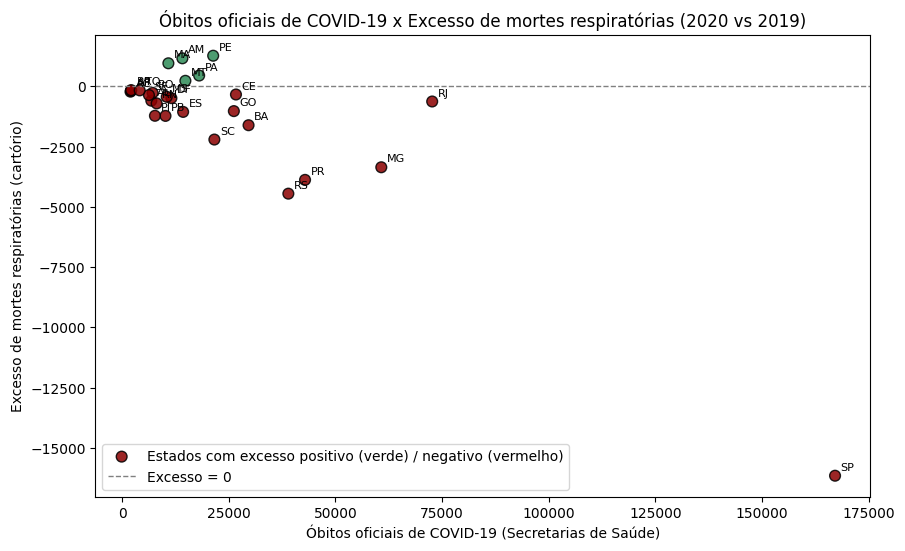

In [ ]:
cores = ["seagreen" if v > 0 else "darkred" for v in state_resp["excesso_resp"]]

plt.figure(figsize=(10, 6))
plt.scatter(state_resp["covid_oficial_saude"], state_resp["excesso_resp"], alpha=0.85, s=60, c=cores, edgecolors="black")
for _, row in state_resp.iterrows():
    plt.annotate(row["state"], (row["covid_oficial_saude"], row["excesso_resp"]), fontsize=8, xytext=(4, 4), textcoords="offset points")

plt.axhline(0, color="gray", linestyle="--", linewidth=1, label="Excesso = 0 (sem excesso)")
plt.title("Óbitos oficiais de COVID-19 x Excesso de mortes respiratórias (2020 vs 2019)")
plt.xlabel("Óbitos oficiais de COVID-19 (Secretarias de Saúde)")
plt.ylabel("Excesso de mortes respiratórias (cartório)")
plt.legend(["Estados com excesso positivo (verde) / negativo (vermelho)", "Excesso = 0"])
plt.show()


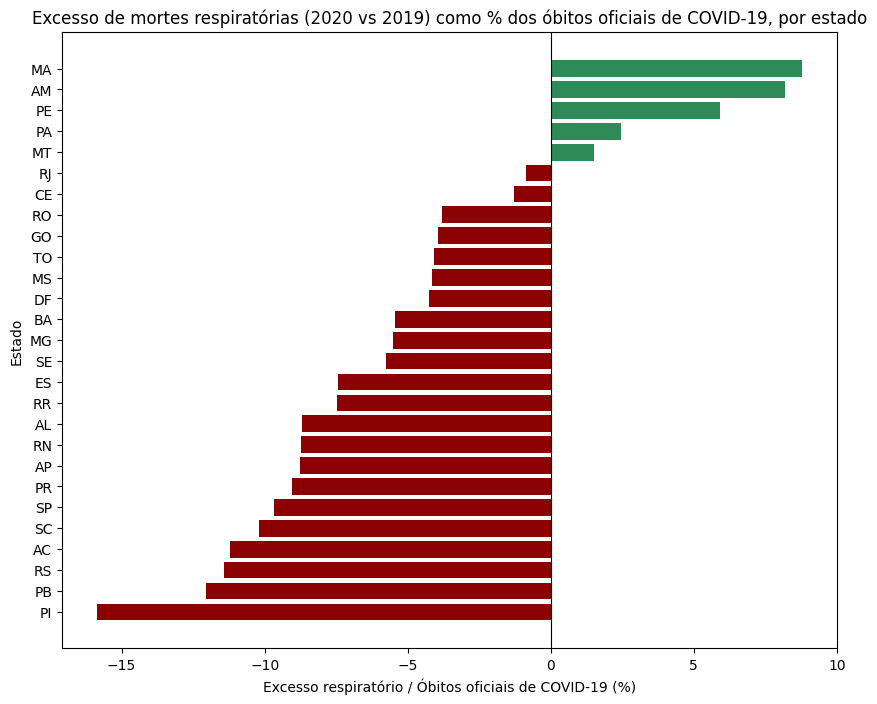

In [ ]:
state_resp_sorted = state_resp.sort_values("razao_excesso_oficial", ascending=False)
cores_bar = ["seagreen" if v > 0 else "darkred" for v in state_resp_sorted["razao_excesso_oficial"]]

plt.figure(figsize=(10, 8))
plt.barh(state_resp_sorted["state"], state_resp_sorted["razao_excesso_oficial"] * 100, color=cores_bar)
plt.axvline(0, color="black", linewidth=0.8)
plt.gca().invert_yaxis()
plt.title("Excesso de mortes respiratórias (2020 vs 2019) como % dos óbitos oficiais de COVID-19, por estado")
plt.xlabel("Excesso respiratório / Óbitos oficiais de COVID-19 (%)")
plt.ylabel("Estado")
plt.show()


**Interpretação:** ao contrário da hipótese inicial de subnotificação generalizada, a maioria dos estados aparece **abaixo** da linha de referência, ou seja, com `excesso_resp` **negativo**, o total de mortes por pneumonia, SARS e insuficiência respiratória caiu em 2020 frente a 2019. Apenas cinco estados apresentaram excesso positivo nessas causas em 2020: **MA (+8,8% do total oficial de óbitos por COVID), AM (+8,2%), PE (+5,9%), PA (+2,5%) e MT (+1,5%)**, todos das regiões Norte/Nordeste. Nos demais estados (majoritariamente Sul/Sudeste, como SP, RJ, MG, RS, PR e SC), o total dessas causas respiratórias caiu entre 1% e 16% em relação a 2019, apesar do grande número de óbitos oficiais por COVID-19 registrados ali. Uma explicação a se considerar é que, nesses estados, os óbitos por COVID-19 foram registrados em sua própria categoria (`deaths_covid19`) e não miscodificados como pneumonia/SARS/insuficiência respiratória, e que o isolamento social reduziu a circulação de outras doenças respiratórias (gripe, pneumonias não-COVID). Além disso, o padrão observado pode ser compatível com um indício de subnotificação concentrado nos estados do Norte/Nordeste, onde a estrutura de testagem e vigilância em saúde é historicamente mais limitada.

**3.6 Pergunta 5 - Evolução temporal das mortes respiratórias (2020 vs. 2019) e relação com a COVID-19**

Nesta etapa, investigamos a dinâmica da mortalidade respiratória sob a influência da pandemia de 2020. O objetivo é analisar se houve um desvio perceptível no padrão sazonal de óbitos por causas respiratórias severas (SRAG, pneumonia e insuficiência respiratória) ao comparar 2020 com 2019. Através de uma análise de série temporal mensal, busca-se identificar se o comportamento dessas causas apresenta associação temporal com a trajetória da COVID-19 no país, permitindo explorar a hipótese de reclassificação diagnóstica e seus efeitos no registro de óbitos.


In [ ]:
df_obito['month'] = df_obito['date'].dt.month
df_mensal = df_obito.groupby('month').sum(numeric_only=True).reset_index()

df_mensal['total_resp_2019'] = df_mensal['new_deaths_sars_2019'] + df_mensal['new_deaths_pneumonia_2019'] + df_mensal['new_deaths_respiratory_failure_2019']
df_mensal['total_resp_2020'] = df_mensal['new_deaths_sars_2020'] + df_mensal['new_deaths_pneumonia_2020'] + df_mensal['new_deaths_respiratory_failure_2020']

colunas_exibicao = ['month', 'total_resp_2019', 'total_resp_2020', 'new_deaths_covid19']
df_final = df_mensal[colunas_exibicao]

display(df_final)

,month,total_resp_2019,total_resp_2020,new_deaths_covid19
0,1,25495.0,25988.0,4.0
1,2,22446.0,23854.0,10.0
2,3,26046.0,28528.0,722.0
3,4,26828.0,28061.0,10070.0
4,5,29524.0,29061.0,28336.0
5,6,30845.0,23926.0,26813.0
6,7,32054.0,23644.0,29647.0
7,8,29592.0,23413.0,26262.0
8,9,27844.0,22241.0,19075.0
9,10,27138.0,23845.0,14476.0


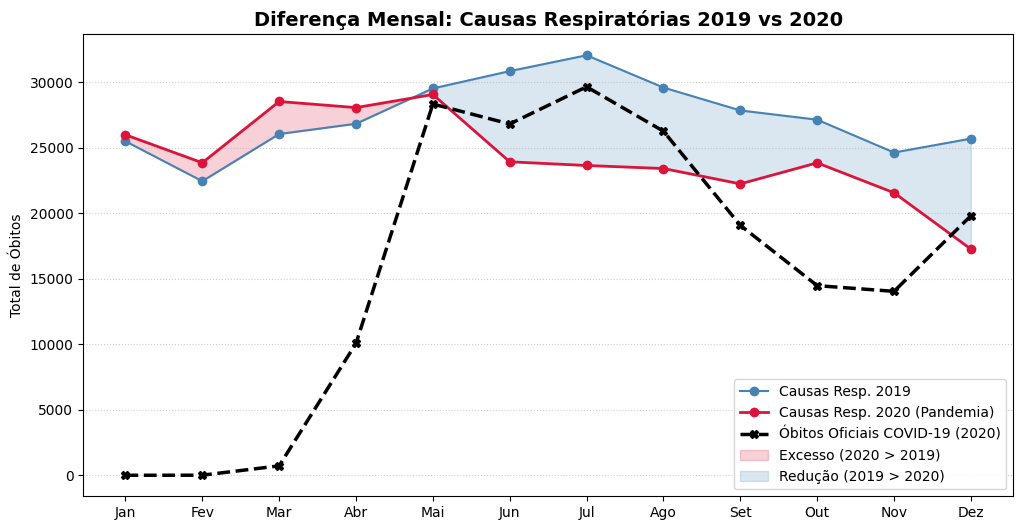

In [ ]:
plt.figure(figsize=(12, 6))


plt.plot(df_mensal['month'], df_mensal['total_resp_2019'], label='Causas Resp. 2019',
         color='steelblue', marker='o', linestyle='-')
plt.plot(df_mensal['month'], df_mensal['total_resp_2020'], label='Causas Resp. 2020 (Pandemia)',
         color='crimson', marker='o', linewidth=2)
plt.plot(df_mensal['month'], df_mensal['new_deaths_covid19'], label='Óbitos Oficiais COVID-19 (2020)',
         color='black', marker='X', linestyle='--', linewidth=2.5)

plt.fill_between(df_mensal['month'], df_mensal['total_resp_2019'], df_mensal['total_resp_2020'],
                 where=(df_mensal['total_resp_2020'] >= df_mensal['total_resp_2019']),
                 interpolate=True, color='crimson', alpha=0.2, label='Excesso (2020 > 2019)')

plt.fill_between(df_mensal['month'], df_mensal['total_resp_2019'], df_mensal['total_resp_2020'],
                 where=(df_mensal['total_resp_2020'] < df_mensal['total_resp_2019']),
                 interpolate=True, color='steelblue', alpha=0.2, label='Redução (2019 > 2020)')

plt.title('Diferença Mensal: Causas Respiratórias 2019 vs 2020', fontsize=14, fontweight='bold')
plt.xticks(range(1, 13), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.ylabel('Total de Óbitos')
plt.legend()
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.show()

**Interpretação:** a análise dos dados mostra que o comportamento das mortes por doenças respiratórias em 2020 foi diferente do esperado. No início do ano, entre janeiro e maio, houve um pequeno aumento nessas mortes, que atingiu o pico em março, antes de a COVID-19 se tornar o foco principal da pandemia no país.
No entanto, a partir de junho, ocorreu uma mudança clara: enquanto as mortes confirmadas por COVID-19 subiam rapidamente (com pico em julho), as mortes registradas por pneumonia, SRAG e insuficiência respiratória caíram abaixo do nível registrado em 2019.
Esse movimento sugere que, à medida que a pandemia avançou, o sistema de saúde passou a identificar e registrar corretamente como COVID-19 casos que antes seriam classificados apenas como doenças respiratórias. Além disso, o isolamento social parece ter reduzido a transmissão de outros vírus respiratórios comuns, contribuindo para essa queda no final do ano. Portanto, os dados sugerem que houve uma melhoria na qualidade do diagnóstico ao longo do tempo, e não uma tentativa de esconder mortes por COVID-19 sob outros nomes.

### (4) Resultados e conclusões

**- Principais resultados encontrados:**
- Há grande heterogeneidade entre os estados brasileiros na incidência normalizada (`confirmed_per_100k_inhabitants`) e na taxa de mortalidade aparente (`death_rate`). Em particular, RJ, SP e MA combinam alta `death_rate` com baixa incidência normalizada, um padrão compatível com menor capacidade de testagem nesses estados (cada caso confirmado tendo, proporcionalmente, mais chance de ter evoluído a óbito).
- A taxa mediana de letalidade (`death_rate`) demonstrou-se semelhante em todos os quartis populacionais, sugerindo que o interior do país foi tão afetado quanto os grandes centros urbanos. A principal diferença identificada foi a volatilidade dos indicadores: municípios menores (quartis Q1 a Q3) concentraram os maiores picos extremos de mortalidade, o que nos leva a deduzir que em populações menores cada óbito tenha um peso estatístico desproporcional.
- A correlação entre porte populacional (em escala log) e incidência normalizada (pergunta 3) é praticamente nula (`r ≈ -0,078`), não havendo evidência de que municípios maiores tenham tido disseminação proporcionalmente mais rápida da doença.
- A comparação entre o excesso de mortes respiratórias (pneumonia + SARS + insuficiência respiratória, usando os incrementos diários `new_deaths_*`) em 2020 frente a 2019 e os óbitos oficiais de COVID-19 por estado (pergunta 4) mostra excesso **positivo** apenas em MA, AM, PE, PA e MT (Norte/Nordeste); em todos os demais estados o total dessas causas respiratórias **caiu** em 2020.
- Os dados sugerem um processo de reclassificação diagnóstica a partir de junho de 2020, em que óbitos anteriormente classificados como "SRAG", "Pneumonia" ou "Insuficiência Respiratória" passaram a ser notificados como "COVID-19".



**- Limitações do dataset:**
- Os dados de óbitos por causas respiratórias (`obito_cartorio`, registros de cartório) e os dados de casos/óbitos por COVID-19 (`caso_full`, notificação das Secretarias de Saúde) têm fontes e metodologias de coleta distintas, o que pode gerar diferenças de cobertura temporal e geográfica entre as bases e dificultar a comparação direta entre elas.
- A base não contém informação de área territorial dos municípios, de modo que a densidade populacional precisou ser aproximada pelo porte populacional (`estimated_population`), o que é uma limitação para a pergunta 3.
- Diferenças na capacidade de testagem entre estados e ao longo do tempo afetam diretamente `confirmed_per_100k_inhabitants` e `death_rate`, podendo distorcer comparações entre regiões com estrutura de saúde muito diferente.

**- Conclusões da análise:**

A análise dos dados evidenciou o impacto da pandemia de COVID-19 no Brasil e que possui métricas difíceis de comparações devido as grandes diferenças socioeconômica do Brasil. Esses achados dialogam diretamente com estudos já publicados sobre a pandemia no país, o que reforça a consistência das interpretações abaixo:
- **Impacto em cidades pequenas:** o impacto da COVID-19 foi observado em todo o território, mas com maior instabilidade nas cidades pequenas, que apresentaram risco maiores devido à menor infraestrutura de saúde local. Esse padrão é consistente com Castro et al. (2021), que mapearam a disseminação da COVID-19 dos grandes centros urbanos em direção ao interior do país e mostraram que desigualdades locais combinadas a respostas de saúde pública tardias produziram cargas de infecção e mortalidade desproporcionalmente altas fora das capitais.
- **Notificação de casos:** foi observado uma subnotificação de casos (quando o número de pessoas infectadas é maior do que o registrado oficialmente), provavelmente pela limitação na capacidade de testagem na região Nordeste. Isso acaba resultando em taxas de letalidades infladas, pois destinavam os poucos testes e confirmações para casos mais graves que evoluíram a óbito. Esse indício de subnotificação concentrada no Norte/Nordeste também foi documentado por Orellana et al. (2021), que encontraram excesso de mortalidade muito acima dos óbitos oficialmente atribuídos à COVID-19 em capitais como Manaus (+112%) e Fortaleza (+72%), e por Ranzani et al. (2021), que registraram mortalidade hospitalar por COVID-19 substancialmente maior nessas regiões, atribuída à menor capacidade estrutural do sistema de saúde local (leitos de UTI, suporte respiratório).
- **Declaração de óbito:** os dados indicam pela análise temporal que pode ter ocorrido miscodificação de óbito, ou seja, eram registrado óbitos com causa incorreta ou imprecisa em vez de COVID-19. Houve aprimoramento e melhor distribuição dos testes em 2020 conforme escalava a pandemia, portanto também ocorreu melhora nos diagnósticos e mortes antes classificadas como inespecíficas ou atribuídas com outras doenças passaram a serem classificadas corretamente como COVID-19. Esse processo de reclassificação diagnóstica é coerente com o descrito por França et al. (2020), que discutem como a demora nos testes e as limitações do sistema de vigilância levaram, no início da pandemia, à subclassificação de óbitos por COVID-19 sob rótulos respiratórios genéricos, sendo corrigida progressivamente à medida que o diagnóstico se aprimorou.

**- Aplicações da análise:**

Os resultados da análise demonstram algumas necessidades de aprimoramento da gestão e da resposta na saúde pública, como: descentralização estratégica de recursos para cidades de menores portes e aprimorar a notificação de causas de mortes desde o início para que não haja inespecificidade de diagnóstico

- **Descentralização de recursos de saúde:** direcionar investimentos em capacidade hospitalar (leitos, UTI, oxigênio) e testagem para municípios pequenos e para as regiões Norte e Nordeste, onde a maior volatilidade da taxa de mortalidade e o indício de subnotificação foram mais evidentes.

- **Padronização da notificação de óbitos:** investir em protocolos de diagnóstico e codificação de causas de morte desde o início de futuras emergências sanitárias, reduzindo o período em que óbitos ficam registrados sob causas inespecíficas (pneumonia, SRAG, insuficiência respiratória) antes de serem corretamente atribuídos à doença causadora.

### (5) Fontes utilizadas

**• Bases de dados:**
- Brasil.io — Boletim epidemiológico COVID-19 (repositório colaborativo, dados agregados a partir das Secretarias Estaduais de Saúde e do Registro Civil/cartórios): https://brasil.io/dataset/covid19/files/
- API pública do Brasil.io: https://brasil.io/api/dataset/covid19/
- Documentação técnica do projeto `covid19-br` (estrutura das variáveis e *endpoints*): https://github.com/turicas/covid19-br/blob/master/api.md

**• Ferramentas e bibliotecas:**
- Python 3, com as bibliotecas `pandas` e `NumPy` (manipulação e limpeza dos dados) e `Matplotlib`/`Seaborn` (visualização e análise exploratória).
- Google Colaboratory como ambiente de execução.

**• Artigos e estudos citados na conclusão:**
- CASTRO, M. C. et al. Spatiotemporal pattern of COVID-19 spread in Brazil. *Science*, v. 372, n. 6544, p. 821–826, 2021. DOI: 10.1126/science.abh1558. Disponível em: https://www.science.org/doi/10.1126/science.abh1558
- RANZANI, O. T. et al. Characterisation of the first 250 000 hospital admissions for COVID-19 in Brazil: a retrospective analysis of nationwide data. *The Lancet Respiratory Medicine*, v. 9, n. 4, p. 407–418, 2021. DOI: 10.1016/S2213-2600(20)30560-9. Disponível em: https://www.thelancet.com/journals/lanres/article/PIIS2213-2600(20)30560-9/fulltext
- ORELLANA, J. D. Y. et al. Excesso de mortes durante a pandemia de COVID-19: subnotificação e desigualdades regionais no Brasil. *Cadernos de Saúde Pública*, v. 37, n. 1, e00259120, 2021. DOI: 10.1590/0102-311X00259120. Disponível em: https://www.scielo.br/j/csp/a/TjDnrpmQBftqgNhtXYPL4Kx/?format=html&lang=pt
- FRANÇA, E. B. et al. Óbitos por COVID-19 no Brasil: quantos e quais estamos identificando? *Revista Brasileira de Epidemiologia*, v. 23, e200053, 2020. DOI: 10.1590/1980-549720200053. Disponível em: https://www.scielosp.org/article/rbepid/2020.v23/e200053/en/